In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from OffManifoldLearning.training import MotorNet, run_singlechannel_trial, calibration, train_singlechannel

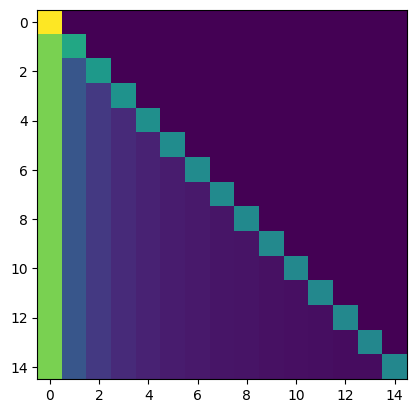

In [20]:
rho = .8
n_channels = 15
Sigma = (1 - rho) * np.eye(n_channels) + rho * np.ones((n_channels, n_channels))
Sigma_half = np.linalg.cholesky(Sigma)

plt.imshow(Sigma_half)

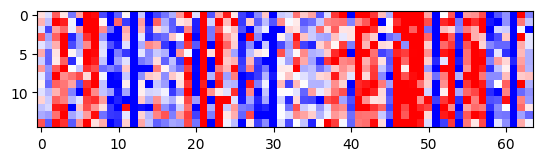

In [21]:
rng = np.random.default_rng(0)

hidden_size = 64
W_out = Sigma_half @ rng.standard_normal((n_channels, hidden_size))   # dense random — creates coupling
#W_out /= np.linalg.norm(W_out, axis=1, keepdims=True)

plt.imshow(W_out, vmin=-1, vmax=1, cmap='bwr')

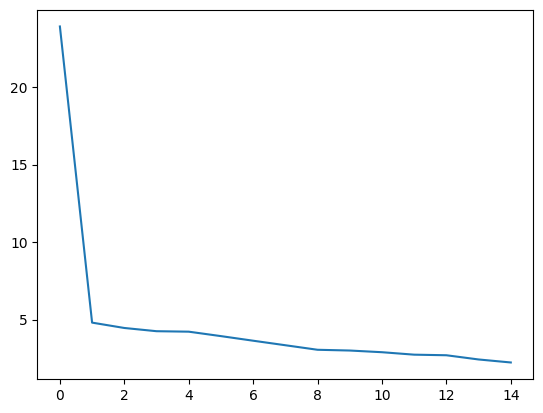

In [22]:
U, s, Vt = np.linalg.svd(W_out)
plt.plot(s)   # flat spectrum = independent channels, decaying = coupled

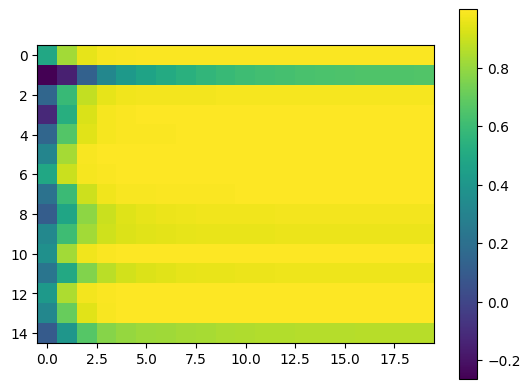

In [23]:
channel = 0
target_force = -1
n_steps = 20

model = MotorNet(task_input_size=17, n_channels=n_channels, hidden_size=hidden_size, readout_matrix=W_out)

f_traj = run_singlechannel_trial(model, channel, target_force, n_steps)

plt.imshow(f_traj.detach().numpy().mean(axis=1).T)
plt.colorbar()

In [24]:
model, loss = train_singlechannel(model, n_epochs=4000)

  Epoch   50 | commanded-channel loss = 0.2557
  Epoch  100 | commanded-channel loss = 0.1556
  Epoch  150 | commanded-channel loss = 0.3082
  Epoch  200 | commanded-channel loss = 0.0451
  Epoch  250 | commanded-channel loss = 0.0456
  Epoch  300 | commanded-channel loss = 0.2036
  Epoch  350 | commanded-channel loss = 0.0464
  Epoch  400 | commanded-channel loss = 1.0561
  Epoch  450 | commanded-channel loss = 0.0992
  Epoch  500 | commanded-channel loss = 0.0241
  Epoch  550 | commanded-channel loss = 0.0707
  Epoch  600 | commanded-channel loss = 0.0771
  Epoch  650 | commanded-channel loss = 0.3433
  Epoch  700 | commanded-channel loss = 0.0156
  Epoch  750 | commanded-channel loss = 0.4139
  Epoch  800 | commanded-channel loss = 0.0705
  Epoch  850 | commanded-channel loss = 0.0086
  Epoch  900 | commanded-channel loss = 0.7555
  Epoch  950 | commanded-channel loss = 0.0494
  Epoch 1000 | commanded-channel loss = 0.0272
  Epoch 1050 | commanded-channel loss = 0.1356
  Epoch 1100 

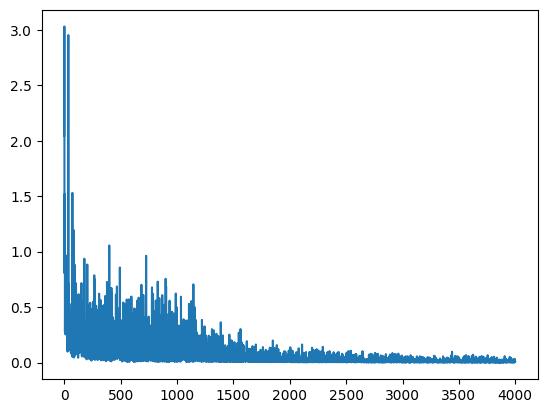

In [25]:
plt.plot(loss)

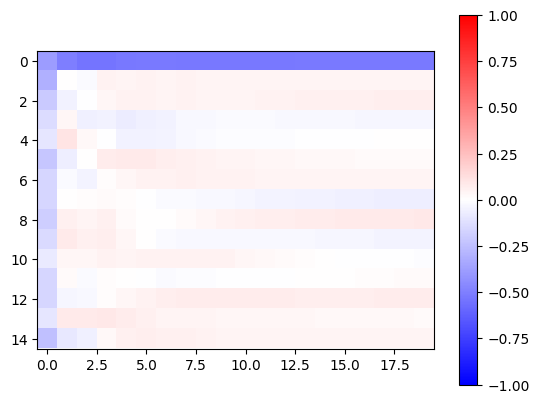

In [26]:
target_force = -.5
f_traj = run_singlechannel_trial(model, channel, target_force, n_steps)

plt.imshow(f_traj.detach().numpy().mean(axis=1).T, vmin=-1, vmax=1, cmap='bwr')
plt.colorbar()

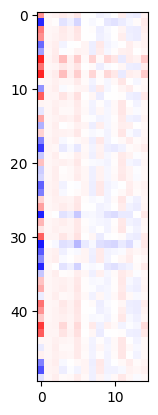

In [27]:
F_sf = calibration(model, n_trials_per_channel=100, n_steps=20)

plt.imshow(F_sf[:50], vmin=-1, vmax=1, cmap='bwr')

estimated intrinsic dimensionality: 12


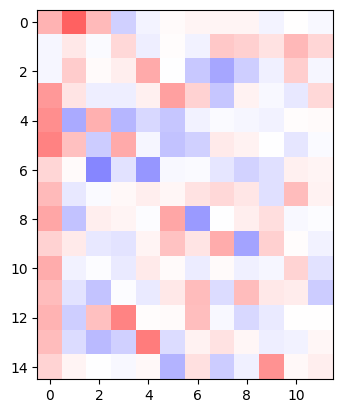

In [28]:
from OffManifoldLearning.factor_analysis import est_dim_crossval, est_intrinsic_manifold

# center single finger
sf_mean = F_sf.mean(axis=0, keepdims=True)
sf_std = F_sf.std(axis=0, keepdims=True)
F_sf_z = (F_sf - sf_mean) / sf_std # z-score

# estimate intrinsic manifold with FA
k, *_ = est_dim_crossval(F_sf_z, k_range=range(2, 15), n_folds=5)
print(f"estimated intrinsic dimensionality: {k}")
L, _ = est_intrinsic_manifold(F_sf_z, k=k)

plt.imshow(L, vmin=-1, vmax=1, cmap='bwr')